In [1]:
from Charts.ploTools import *
from Charts.resumeTools import *
from glob import glob

In [2]:
def getDataResumeFromPREFIX(PREFIX_TO_GET):
    PATH_DATA_LIST_METRICS_RESUME = glob(PREFIX_TO_GET + "/metrics_resume.pkl")
    PATH_DATA_LIST_METRICS_RESUME_TESTING  = glob(PREFIX_TO_GET + "/metrics_resume_testing.pkl")
    PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_TO_GET + "/training_rewards_resume.pkl")

    metrics_resume_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME)
    metrics_resume_testing_avg = mean_resume_data(PATH_DATA_LIST_METRICS_RESUME_TESTING)
    training_rewards_resume_avg = mean_training_reward_data(PATH_DATA_LIST_TRAINING_REWARDS_RESUME)

    return metrics_resume_avg, metrics_resume_testing_avg, training_rewards_resume_avg

In [3]:
# PREFIX_EXP = "OptimizeIterationsResults/OptunaDDPGExpBase/00000*/*" # Base
PREFIX_EXP_0 = "OptimizeIterationsResults/OptunaDDPGExpBase_Total/00000*/*" # 
PREFIX_EXP_1 = "OptimizeIterationsResults/OptunaDDPGExpBase_CorrelationPunishment05/00000*/*" #
PREFIX_EXP_2 = "OptimizeIterationsResults/OptunaDDPGExpBase_CorrelationPunishment07/00000*/*" #

#glob(f"{PREFIX_EXP_1}/*.pkl")
print(f"Existen {len(glob(f'{PREFIX_EXP_0}/*.pkl'))} experimentos con la configuración 0 \
y {len(glob(f'{PREFIX_EXP_1}/*.pkl'))} con la configuración 1")

#El primero debe ser el base siempre
EXPERIMENTS = [PREFIX_EXP_0, PREFIX_EXP_1,PREFIX_EXP_2]

Existen 400 experimentos con la configuración 0 y 400 con la configuración 1


In [4]:
# Procesamos el base
Final_metrics_resume_avg = {}
Final_metrics_resume_testing_avg = {}
Final_training_rewards_resume_avg = {}

BASE = EXPERIMENTS.pop(0)

BASE_metrics_resume_avg, BASE_metrics_resume_testing_avg, BASE_training_rewards_resume_avg = getDataResumeFromPREFIX(BASE)

In [5]:
Final_metrics_resume_avg['DDPG_Base'] = BASE_metrics_resume_avg['DDPG Agent']
#Final_metrics_resume_avg['SP500'] = BASE_metrics_resume_avg['SP500 Agent']

Final_metrics_resume_testing_avg['DDPG_Base'] = BASE_metrics_resume_testing_avg['DDPG Agent']
#Final_metrics_resume_testing_avg['SP 500'] = BASE_metrics_resume_testing_avg['SP500 Agent']

Final_training_rewards_resume_avg['DDPG_Base'] = BASE_training_rewards_resume_avg['DDPG Agent']
#Final_training_rewards_resume_avg['SP500'] = BASE_training_rewards_resume_avg['SP500 Agent']

for EXP in EXPERIMENTS:
    SUBFIX_END = EXP.split('/')[1].split('OptunaDDPGExp')[1].split('_')[-1]
    SUBFIX = f'DDPG_{SUBFIX_END}'
    metrics_resume_avg, metrics_resume_testing_avg, training_rewards_resume_avg = getDataResumeFromPREFIX(EXP)

    Final_metrics_resume_avg[SUBFIX] = metrics_resume_avg['DDPG Agent']
    Final_metrics_resume_testing_avg[SUBFIX] = metrics_resume_testing_avg['DDPG Agent']
    Final_training_rewards_resume_avg[SUBFIX] = training_rewards_resume_avg['DDPG Agent']


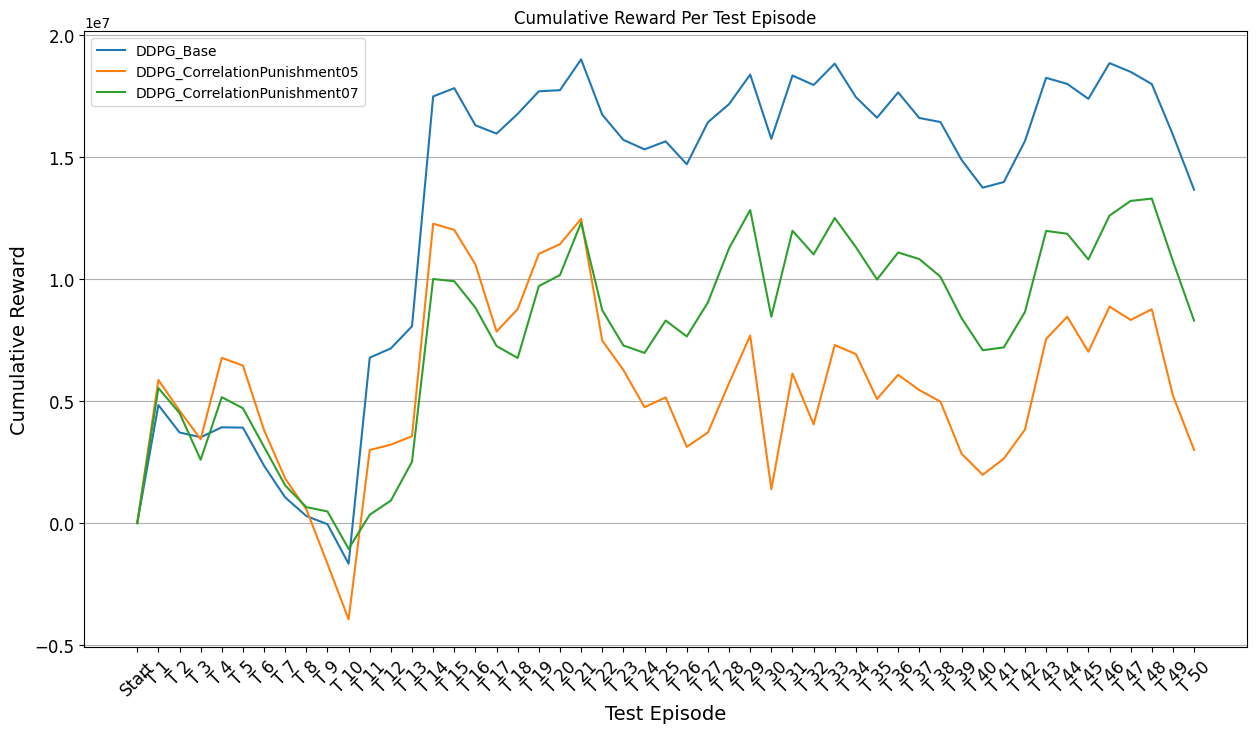

In [6]:
# No comparables
# Output 2 - Training Rewards - last Agent
plotCumulativeRewardMultiAgents(Final_metrics_resume_avg)

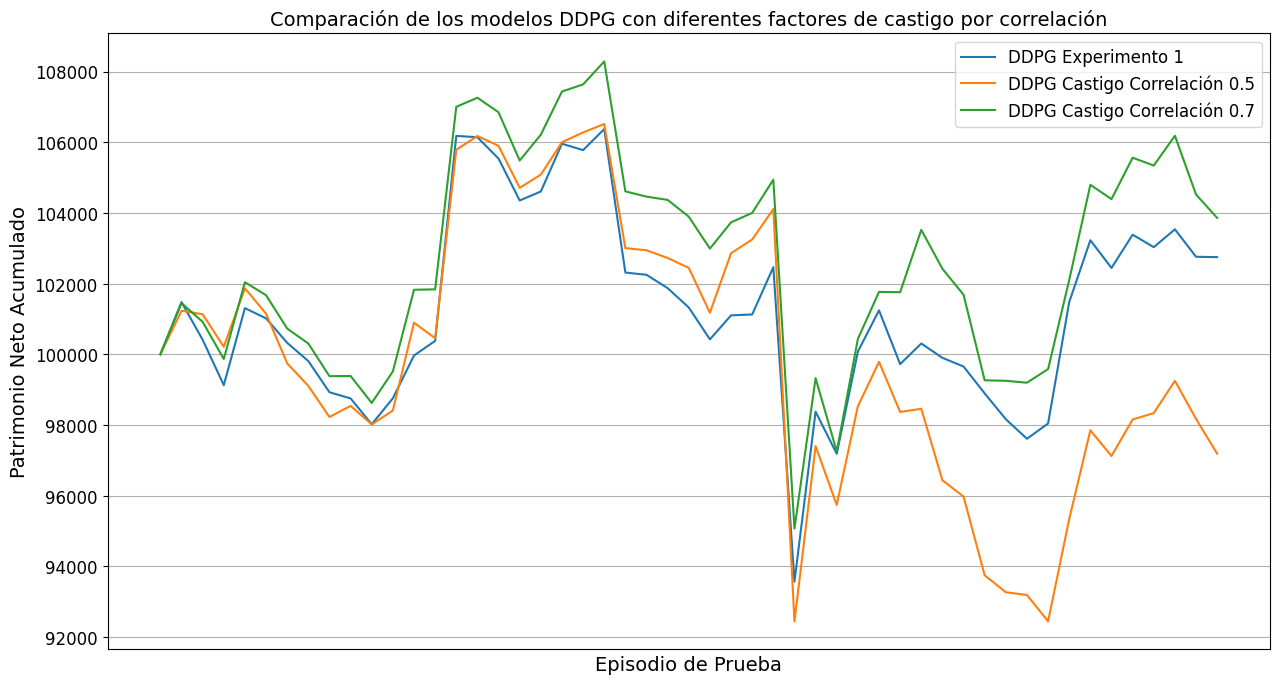

In [6]:
# Output 4 - Cumulative Networth - last Agent
label_list_dict = {'DDPG_Base': 'DDPG Experimento 1', 
                   'DDPG_CorrelationPunishment05': 'DDPG Castigo Correlación 0.5',
                   'DDPG_CorrelationPunishment07': 'DDPG Castigo Correlación 0.7',
                   'title': 'Comparación de los modelos DDPG con diferentes factores de castigo por correlación',
                   'xlabel': 'Episodio de Prueba',
                   'ylabel': 'Patrimonio Neto Acumulado',}
result0 = plotCumulativeNetWorthMultiAgents(Final_metrics_resume_testing_avg, path_to_save="G6_PivotCorrelationPunishment", label_list_dict=label_list_dict)

In [7]:
result0.keys()

dict_keys(['DDPG Experimento 1', 'DDPG Castigo Correlación 0.5', 'DDPG Castigo Correlación 0.7'])

In [9]:
import pandas as pd
#pd.DataFrame.from_dict(result0['DDPG Agent'])
agentName = 'DDPG Castigo Correlación 0.7'
df = pd.DataFrame(data=[['T 0'] + result0[agentName]['dates'] , result0[agentName]['patAcum']]).T
df.columns  = ['Time', 'patAcum']
df['Serie'] = agentName
df.to_csv(f'dataChartsForPaper/{agentName}patAcum.csv',index=False)

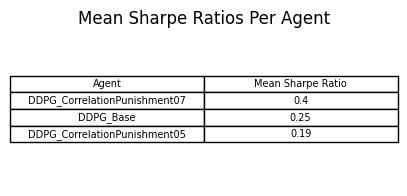

In [10]:
# Output 5 - Ratio Sharpe Table
# T1
plotTableMeanSharpeRatioMultiAgents(Final_metrics_resume_testing_avg)

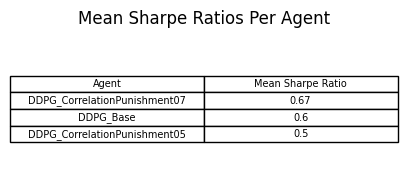

In [17]:
plotTableMeanSharpeRatioMultiAgents(Final_metrics_resume_avg)

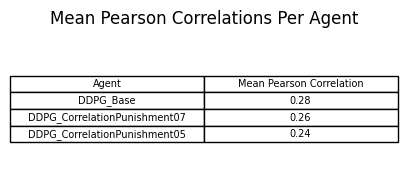

In [11]:
#T2
# Output 8.2 - Pearson Correlation Table
plotTableMeanPearsonCorrelationMultiAgents(Final_metrics_resume_testing_avg)